# Data cleaning

In this file, we aggregate river flow data to monthly values (raw data has daily values), and then log transform it. We also temporally interpolate features to monthly scale, and produce a file containing all features and responses on monthly time scales. 

In [178]:
#loading packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime, timedelta

### River Flow Data Cleaning

Loading river data

In [179]:
salt_outflow = pd.read_csv("../Data/RawData/DailyFlow_SaltDownstream.csv")
salt_inflow = pd.read_csv("../Data/RawData/DailyFlow_SaltUpstream.csv")
verde_outflow = pd.read_csv("../Data/RawData/DailyFlow_VerdeDownstream.csv")
verde_inflow = pd.read_csv("../Data/RawData/DailyFlow_VerdeUpstream.csv")

In [180]:
#checking one of the dataframes
salt_outflow.head()

,x,y,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified
0,-111.576543,33.552841,2057fc3c33ce4e689bfa2c35d2c88387,USGS-09502000,60,3,2026-06-11,736.0,ft^3/s,Provisional,NaN,2026-06-12 09:05:13.660820+00:00
1,-111.576543,33.552841,2057fc3c33ce4e689bfa2c35d2c88387,USGS-09502000,60,3,2026-06-10,768.0,ft^3/s,Provisional,NaN,2026-06-11 09:05:18.362082+00:00
2,-111.576543,33.552841,2057fc3c33ce4e689bfa2c35d2c88387,USGS-09502000,60,3,2026-06-09,703.0,ft^3/s,Provisional,NaN,2026-06-10 09:05:02.080488+00:00
3,-111.576543,33.552841,2057fc3c33ce4e689bfa2c35d2c88387,USGS-09502000,60,3,2026-06-08,670.0,ft^3/s,Provisional,NaN,2026-06-09 09:05:04.440256+00:00
4,-111.576543,33.552841,2057fc3c33ce4e689bfa2c35d2c88387,USGS-09502000,60,3,2026-06-07,687.0,ft^3/s,Provisional,NaN,2026-06-08 09:05:05.149536+00:00


Creating list of dataframe names (to make it easier to modify all 4 dataframes without having to type out the same code multiple times)

In [181]:
#creating list of dataframe names
riverflow_list = ["salt_inflow", "salt_outflow", "verde_inflow", "verde_outflow"]

Removing provisional data, converting date column to datetime format, and ordering rows by date

In [182]:
for i in riverflow_list:
    #removing provisional data
    globals()[i] = globals()[i][globals()[i].approval_status != "Provisional"] 

    #converting time column to datetime format
    globals()[i]["time"] = pd.to_datetime(globals()[i]["time"])

    #sorting values by date (oldest to newest)
    globals()[i] = globals()[i].sort_values("time", ascending=True)


In [183]:
#checking that provisional data got removed
print(salt_inflow.approval_status.value_counts())
print(salt_outflow.approval_status.value_counts())

approval_status
Approved    40815
Name: count, dtype: int64
approval_status
Approved    32006
Name: count, dtype: int64


In [184]:
#checking whether the time columns got successfully converted 
print(salt_outflow.time.dtype)
print(salt_inflow.time.dtype)
print(verde_inflow.time.dtype)
print(verde_inflow.time.dtype)

datetime64[us]
datetime64[us]
datetime64[us]
datetime64[us]


Removing columns that are not needed and only keeping the 'time' and 'value' columns.

In [185]:
for i in riverflow_list:
    #selecting only the time and value columns
    globals()[i] = globals()[i][["time", "value"]] 
    print(i, globals()[i].columns)

#checking one of the dataframes
verde_inflow.head()

salt_inflow Index(['time', 'value'], dtype='str')
salt_outflow Index(['time', 'value'], dtype='str')
verde_inflow Index(['time', 'value'], dtype='str')
verde_outflow Index(['time', 'value'], dtype='str')


,time,value
29510,1945-08-22,257.0
29509,1945-08-23,234.0
29508,1945-08-24,206.0
29507,1945-08-25,199.0
29506,1945-08-26,302.0


Aggregating daily data to monthly scales by averaging over each month

In [186]:
for i in riverflow_list:
    #selecting only the time and value columns
    globals()[i].set_index("time", inplace=True, drop = False)
    
    #creating a name for the monthly data df
    name = "monthly_" + i

    #calculating monthly flow rates
    globals()[name] = globals()[i].resample("MS").agg({"value":"mean"})

    #ordering rows of monthly dataframe by time (newest to oldest)
    globals()[name] = globals()[name].sort_values("time", ascending=False)

    #adding column for log-transformed flow rate
    globals()[name]["log_value"] = np.log(globals()[name].value + 1)

    #adding time column
    globals()[name]["Time"] = globals()[name].index



In [187]:
#checking one of the dataframes
monthly_salt_inflow.head()

,value,log_value,Time
time,,,
2025-06-01,66.948276,4.218747,2025-06-01
2025-05-01,94.509677,4.559228,2025-05-01
2025-04-01,126.866667,4.850988,2025-04-01
2025-03-01,157.193548,5.063819,2025-03-01
2025-02-01,130.464286,4.878735,2025-02-01


#### River data plots

Histograms of average monthly flow rates

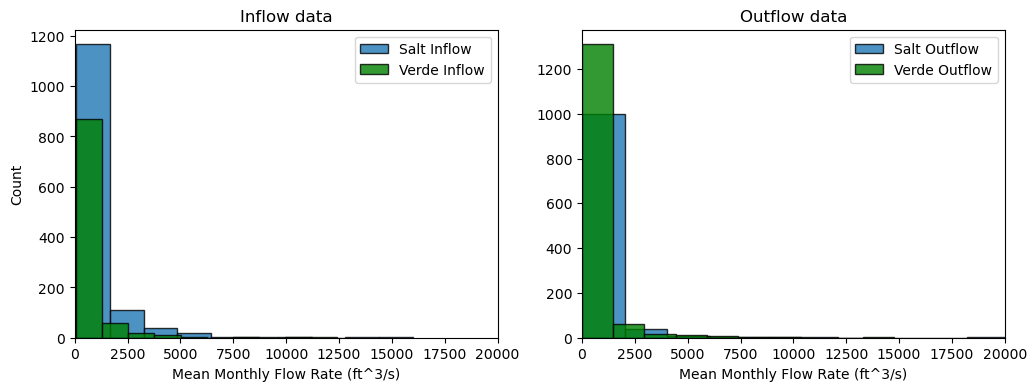

In [188]:
fig, ax = plt.subplots(1,2, figsize = (12,4))

ax[0].hist(monthly_salt_inflow.value, edgecolor = "black", label="Salt Inflow", alpha = 0.8)
ax[0].hist(monthly_verde_inflow.value, edgecolor = "black",color = "green", label="Verde Inflow", alpha= 0.8)
ax[0].set_title("Inflow data")
ax[0].legend()
ax[0].set_xlabel("Mean Monthly Flow Rate (ft^3/s)")
ax[0].set_ylabel("Count")
ax[0].set_xlim(0, 20000)

ax[1].hist(monthly_salt_outflow.value, edgecolor = "black", label="Salt Outflow", alpha= 0.8)
ax[1].hist(monthly_verde_outflow.value, edgecolor = "black",color ="green", label="Verde Outflow", alpha= 0.8)
ax[1].set_title("Outflow data")
ax[1].legend()
ax[1].set_xlabel("Mean Monthly Flow Rate (ft^3/s)")
ax[1].set_xlim(0, 20000)
plt.show()

Time series plots

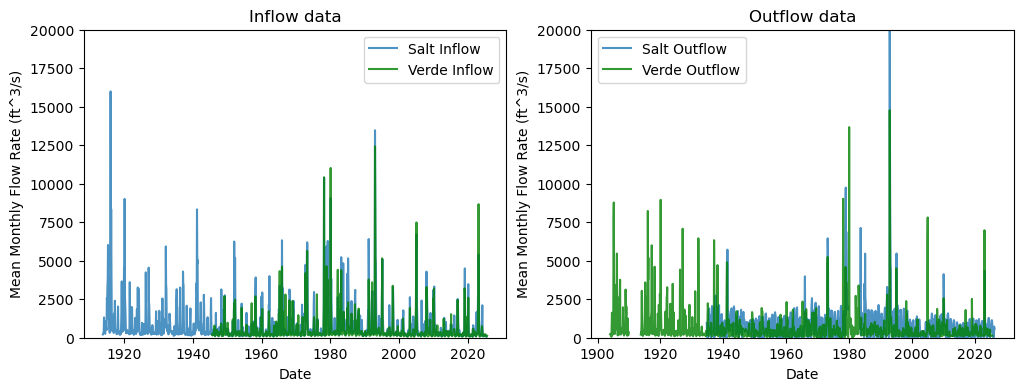

In [189]:
fig, ax = plt.subplots(1,2, figsize = (12,4))

ax[0].plot(monthly_salt_inflow.value, label="Salt Inflow", alpha = 0.8)
ax[0].plot(monthly_verde_inflow.value,  label="Verde Inflow",color ="green",  alpha= 0.8)
ax[0].set_title("Inflow data")
ax[0].legend()
ax[0].set_ylabel("Mean Monthly Flow Rate (ft^3/s)")
ax[0].set_xlabel("Date")
ax[0].set_ylim(0, 20000)

ax[1].plot(monthly_salt_outflow.value, label="Salt Outflow", alpha= 0.8)
ax[1].plot(monthly_verde_outflow.value, label="Verde Outflow", color ="green", alpha= 0.8)
ax[1].set_title("Outflow data")
ax[1].legend()
ax[1].set_ylabel("Mean Monthly Flow Rate (ft^3/s)")
ax[1].set_xlabel("Date")
ax[1].set_ylim(0, 20000)
plt.show()

Sometimes the outflow is higher than the inflow!

The data is very skewed and has large outliers, that's why we log-transformed it. Below we plot the log transformed data

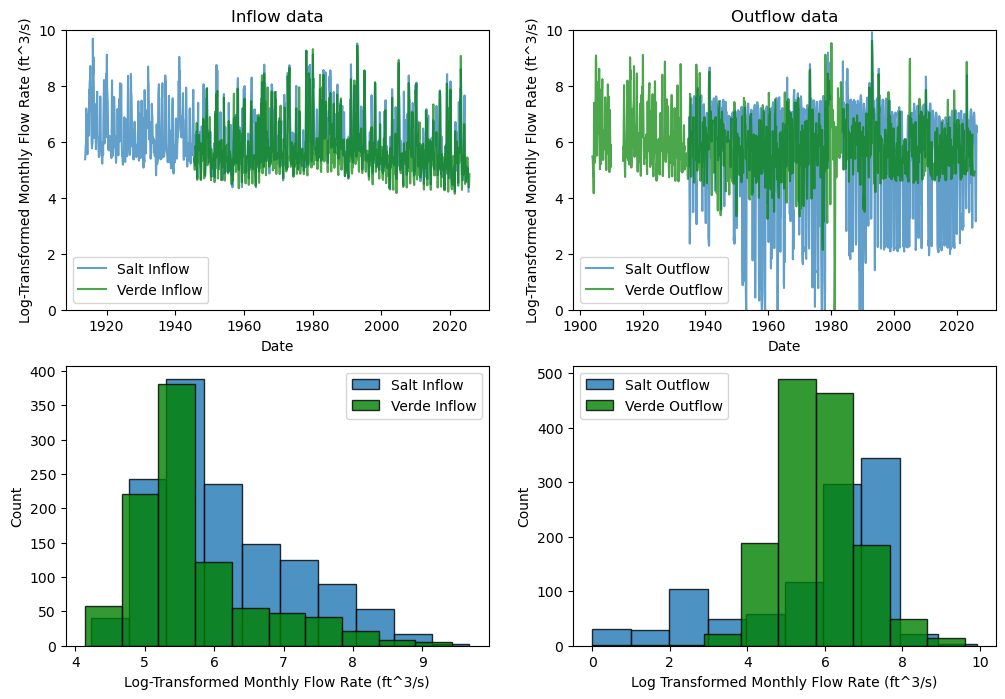

In [190]:
fig, ax = plt.subplots(2,2, figsize = (12,8))

ax[0,0].plot(monthly_salt_inflow.log_value, label="Salt Inflow", alpha = 0.7)
ax[0,0].plot(monthly_verde_inflow.log_value,  label="Verde Inflow",color ="green",  alpha= 0.7)
ax[0,0].set_title("Inflow data")
ax[0,0].legend()
ax[0,0].set_ylabel("Log-Transformed Monthly Flow Rate (ft^3/s)")
ax[0,0].set_xlabel("Date")
ax[0,0].set_ylim(0,10)

ax[0,1].plot(monthly_salt_outflow.log_value, label="Salt Outflow", alpha= 0.7)
ax[0,1].plot(monthly_verde_outflow.log_value, label="Verde Outflow", color ="green", alpha= 0.7)
ax[0,1].set_title("Outflow data")
ax[0,1].legend()
ax[0,1].set_ylabel("Log-Transformed Monthly Flow Rate (ft^3/s)")
ax[0,1].set_xlabel("Date")
ax[0,1].set_ylim(0,10)

ax[1,0].hist(monthly_salt_inflow.log_value, edgecolor = "black", label="Salt Inflow", alpha = 0.8)
ax[1,0].hist(monthly_verde_inflow.log_value, edgecolor = "black",color = "green", label="Verde Inflow", alpha= 0.8)
ax[1,0].legend()
ax[1,0].set_xlabel("Log-Transformed Monthly Flow Rate (ft^3/s)")
ax[1,0].set_ylabel("Count")

ax[1,1].hist(monthly_salt_outflow.log_value, edgecolor = "black", label="Salt Outflow", alpha= 0.8)
ax[1,1].hist(monthly_verde_outflow.log_value, edgecolor = "black",color ="green", label="Verde Outflow", alpha= 0.8)
ax[1,1].legend()
ax[1,1].set_xlabel("Log Transformed Monthly Flow Rate (ft^3/s)")
ax[1,1].set_ylabel("Count")
plt.show()

### Climate Data

Climate data is already at monthly scale. We just need to filter out data that is outside the time range of the river flow data, and convert the time column to datetime format

Loading data and converting Time column to datetime format

In [191]:
climate_watershed = pd.read_csv("../Data/FormattedData/Climate_Watersheds.csv")
climate_maricopa = pd.read_csv("../Data/FormattedData/Climate_MaricopaCounty.csv").rename(columns ={"Temp":"Temp_Maricopa",
                                                                                                    "Precip":"Precip_Maricopa"})

#converting time column to datetime format
climate_watershed["Time"] = pd.to_datetime(climate_watershed.Time)
climate_maricopa["Time"] = pd.to_datetime(climate_maricopa.Time)

climate_watershed.head()

,Time,Temp_Salt,Temp_Verde,Precip_Salt,Precip_Verde
0,1895-01-01,2.016537,1.548778,71669.250,134251.9400
1,1895-02-01,2.488735,3.575411,17260.508,12643.4640
2,1895-03-01,5.915051,7.470766,4439.287,9704.5400
3,1895-04-01,9.875881,12.606539,2930.791,1849.8154
4,1895-05-01,14.626182,15.331393,10896.962,8430.8810


In [192]:
climate_maricopa.head()

,Time,Temp_Maricopa,Precip_Maricopa
0,1895-01-01,11.525407,74211.4840
1,1895-02-01,13.477033,5563.9630
2,1895-03-01,15.974886,1110.3701
3,1895-04-01,20.032337,296.8828
4,1895-05-01,23.890900,1550.4785


In [193]:
print(climate_maricopa.Time.dtype)
print(climate_watershed.Time.dtype)

datetime64[us]
datetime64[us]


Identifying the earliest date for which river flow data is available, and filtering climate data to only keep data from that date onwards

In [194]:
#finding the earliest date for which river flow data is available
first_dates_flow = [monthly_salt_inflow.Time.min(), 
                   monthly_salt_outflow.Time.min(), 
                   monthly_verde_inflow.Time.min(),
                   monthly_verde_outflow.Time.min()]
earliest_data_date = min([datetime.strptime(date, "%Y-%m-%d").date() for date in first_date_flow])
earliest_data_date = pd.Timestamp(earliest_data_date)
print(earliest_data_date)

#filtering climate data based on earliest data date
climate_maricopa = climate_maricopa[climate_maricopa.Time>=earliest_data_date]
climate_watershed = climate_watershed[climate_watershed.Time>=earliest_data_date]
climate_watershed.head()

1904-01-01 00:00:00


,Time,Temp_Salt,Temp_Verde,Precip_Salt,Precip_Verde
108,1904-01-01,0.412272,0.778270,11437.80400,6026.1006
109,1904-02-01,6.591203,6.846608,13666.66000,13582.5440
110,1904-03-01,8.836679,8.737621,8067.42600,14928.8310
111,1904-04-01,11.181077,11.063109,869.83984,1075.0176
112,1904-05-01,15.238901,15.235604,8276.78600,13574.9830


### Farmland area/irrigated farmland area in Maricopa county

In [195]:
farmland = pd.read_csv("../Data/RawData/Maricopa_Farmland_Area.csv")
farmland.head()

,Year,TotalFarmland_Acres,IrrigatedLand_Acres,Notes
0,1930,578350,NaN,NaN
1,1935,683944,NaN,NaN
2,1940,1122211,307319.0,estimated from irrigated pasture + irrigated c...
3,1945,1041210,NaN,NaN
4,1950,2373343,461263.0,NaN


Data for irrigated acres was not available for certain censuses. We will fill in those values using a linear regression of irrigated acres vs total farmland area

In [196]:
from sklearn.linear_model import LinearRegression

#selecting rows that have data for both irrigated acreas and total farmland area
farmland_not_missing = farmland.dropna(subset = ["IrrigatedLand_Acres"])

#selecting rows that have data for only total farmland area
farmland_missing_irrigated = farmland[farmland.IrrigatedLand_Acres.isna()]

#fitting linear model and predicting missing values
lm = LinearRegression(fit_intercept=False) #intercept should be zero because irrigated farmland has to be zero when there is no farmland
lm.fit(farmland_not_missing[["TotalFarmland_Acres"]], farmland_not_missing[["IrrigatedLand_Acres"]])
farmland_missing_irrigated["IrrigatedLand_Acres"] = np.round(lm.predict(farmland_missing_irrigated[["TotalFarmland_Acres"]]))
farmland_missing_irrigated

,Year,TotalFarmland_Acres,IrrigatedLand_Acres,Notes
0,1930,578350,126889.0,NaN
1,1935,683944,150057.0,NaN
3,1945,1041210,228440.0,NaN


In [197]:
#replacing missing values with predicted values 
farmland.loc[farmland.IrrigatedLand_Acres.isna(), ["IrrigatedLand_Acres"]] = farmland_missing_irrigated.IrrigatedLand_Acres
farmland.head()

,Year,TotalFarmland_Acres,IrrigatedLand_Acres,Notes
0,1930,578350,126889.0,NaN
1,1935,683944,150057.0,NaN
2,1940,1122211,307319.0,estimated from irrigated pasture + irrigated c...
3,1945,1041210,228440.0,NaN
4,1950,2373343,461263.0,NaN


We will now linearly interpolate the data to monthly timescales

In [198]:
#converting year column to datetime format
farmland["Time"] = pd.to_datetime(farmland["Year"].astype(str) + "-01-01")

#setting the time column as the index
farmland.set_index("Time", inplace=True, drop=False)

#creating a monthly date index
monthly_index = pd.date_range(
    start=farmland.index.min(),
    end="2026-5-01",
    freq="MS"      # Month Start
)

#eeindexing and interpolating
farmland_monthly = (
    farmland[["IrrigatedLand_Acres"]]
    .reindex(monthly_index)
    .interpolate(method="time"))

#adding a time column
farmland_monthly["Time"] = farmland_monthly.index

In [199]:
farmland_monthly.head()

,IrrigatedLand_Acres,Time
1930-01-01,126889.000000,1930-01-01
1930-02-01,127282.323111,1930-02-01
1930-03-01,127637.582694,1930-03-01
1930-04-01,128030.905805,1930-04-01
1930-05-01,128411.541073,1930-05-01


Note: The latest farmland data is from 2022, so we had to assume that the values stay constant after 2022.

### Population data

Loading population data (population data is in four separate files! Also we have annual data from 1970 onwards but only decadal data from before 1970)

In [200]:
#Decadal population data from National Historic Geographic Information System
pop_nhgis = pd.read_csv("../Data/RawData/Population/DecadalPopulation_1920-2020_NHGIS.csv")

#Annual data from 1970-2014 from National Bureau of Economic Research
pop_nber = pd.read_csv("../Data/RawData/Population/AnnualPopulation_1970-2014_NBER.csv",  encoding='latin-1')

#Annual data from 2010 to 2019 and from 2020 to 2025 from US Census Bureau
pop_uscb_2010s =  pd.read_csv("../Data/RawData/Population/AnnualPopulation_2010-2019_USCB.csv")
pop_uscb_2020s = pd.read_csv("../Data/RawData/Population/AnnualPopulation_2020-2025_USCB.csv")

Filtering each data frame to keep only Maricopa County and removing extra columns

In [201]:
pop_nhgis = pop_nhgis[(pop_nhgis.STATE=="Arizona") & (pop_nhgis.COUNTY =="Maricopa County")]
pop_nhgis = pop_nhgis.loc[:,"A00AA1920":"A00AA1960"] #selecting data from 1920 to 1960
pop_nhgis

,A00AA1920,A00AA1930,A00AA1940,A00AA1950,A00AA1960
7,89576.0,150970.0,186193.0,331770.0,663510.0


In [202]:
pop_nber = pop_nber[ (pop_nber.county_name=="Maricopa County")] 
pop_nber = pop_nber.loc[:, "pop1970":"pop2014"]
pop_nber

,pop1970,pop1971,pop1972,pop1973,pop1974,pop1975,pop1976,pop1977,pop1978,pop1979,...,pop2008,pop2009,pop19904,pop20104,base20104,pop2010,pop2011,pop2012,pop2013,pop2014
215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3817117.0,3817357.0,3823609.0,3870076.0,3942868.0,4013164.0,4087191.0
216,971228.0,1026400.0,1087200.0,1156700.0,1217400.0,1253900.0,1280000.0,1329800.0,1388900.0,1456800.0,...,3958263.0,4023132.0,2122101.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [203]:
#in the NBER file, there are two rows for Maricopa County, so we need to combine them
pop_nber = pop_nber.sum(axis=0)
pop_nber.head()

pop1970     971228.0
pop1971    1026400.0
pop1972    1087200.0
pop1973    1156700.0
pop1974    1217400.0
dtype: float64

In [204]:
pop_uscb_2010s = pop_uscb_2010s[pop_uscb_2010s.GeographicArea ==".Maricopa County, Arizona"]
pop_uscb_2010s = pop_uscb_2010s.loc[:, "2015":"2019"]
pop_uscb_2010s

,2015,2016,2017,2018,2019
8,4101119,4170720,4227971,4290093,4363090


In [205]:
pop_uscb_2020s =pop_uscb_2020s[pop_uscb_2020s.GeographicArea ==".Maricopa County, Arizona"]
pop_uscb_2020s = pop_uscb_2020s.loc[:, "April2020_Census":"2025"]
pop_uscb_2020s

,April2020_Census,2020,2021,2022,2023,2024,2025
8,4425302,4445025,4500059,4559561,4601077,4654147,4689558


Now we will convert these dataframes to long format (one row for each year)

In [206]:
pop_nhgis_long = pd.melt(pop_nhgis, var_name="Year", 
                         value_name="Population")
pop_nber_long = pd.DataFrame({"Year":pop_nber.index,
                              "Population":pop_nber})
pop_uscb_2010s_long = pd.melt(pop_uscb_2010s, var_name="Year", 
                              value_name="Population")
pop_uscb_2020s_long = pd.melt(pop_uscb_2020s, var_name="Year", 
                              value_name="Population")

#removing strange year values from the NBER dataframe
pop_nber_long = pop_nber_long[pop_nber_long.Year!="base20104"]
pop_nber_long = pop_nber_long[pop_nber_long.Year!="pop20104"]
pop_nber_long = pop_nber_long[pop_nber_long.Year!="pop19904"]

#there are two values for 2020 in the USCB 2020s dataset, so one of them needs to be removed
pop_uscb_2020s_long = pop_uscb_2020s_long[pop_uscb_2020s_long.Year!="2020"]
pop_uscb_2020s_long.iloc[0,0] = "2020"

#removing extra characters from year column
pop_nhgis_long["Year"] = pop_nhgis_long.Year.apply(lambda x:int(x[5:]))
pop_nber_long["Year"] = pop_nber_long.Year.apply(lambda x:int(x[3:]))
pop_nhgis_long.head()

,Year,Population
0,1920,89576.0
1,1930,150970.0
2,1940,186193.0
3,1950,331770.0
4,1960,663510.0


In [207]:
pop_nber_long.head()

,Year,Population
pop1970,1970,971228.0
pop1971,1971,1026400.0
pop1972,1972,1087200.0
pop1973,1973,1156700.0
pop1974,1974,1217400.0


In [208]:
pop_uscb_2020s_long

,Year,Population
0,2020,4425302
2,2021,4500059
3,2022,4559561
4,2023,4601077
5,2024,4654147
6,2025,4689558


Combining all the population dataframes and linearly interpolating to monthly timescale

In [209]:
#stacking dataframes
population = pd.concat([pop_nhgis_long,pop_nber_long,pop_uscb_2010s_long,pop_uscb_2020s_long], ignore_index=True)

#converting year column to a datetime format
population["Time"] = pd.to_datetime(population["Year"].astype(str) + "-01-01")
population = population.sort_values("Time") #sorting by time from oldest to latest

#indexing by time column
population.set_index("Time", inplace=True, drop=False)

#creating a monthly date index
monthly_index = pd.date_range(
    start=population.index.min(),
    end="2026-5-01",
    freq="MS"      # Month Start
)

#eeindexing and interpolating
population_monthly = (
    population[["Population"]]
    .reindex(monthly_index)
    .interpolate(method="time"))

#adding a time column
population_monthly["Time"] = population_monthly.index

In [210]:
population_monthly.head()

,Population,Time
1920-01-01,89576.000000,1920-01-01
1920-02-01,90097.000274,1920-02-01
1920-03-01,90584.387627,1920-03-01
1920-04-01,91105.387900,1920-04-01
1920-05-01,91609.581714,1920-05-01


### Data centers

Loading file

In [211]:
#Loading  the data center file
datacenters = pd.read_csv('../Data/RawData/phoenix_datacenters_chronological.csv')

#Keeping only the necessary columns 
datacenters = datacenters[['Initial_Operational_Year', 'Operational_MW_Capacity']]

datacenters.head()

,Initial_Operational_Year,Operational_MW_Capacity
0,2012,54
1,2014,41
2,2016,60
3,2018,210
4,2019,40


Calculating number of data centers and total capacity for each month of each year

In [212]:
#Buildling an empty dataframe with one row for each month
months = pd.date_range(start='2012-01-01', end='2026-05-01', freq='MS')
datacenters_monthly = pd.DataFrame({'Time': months})

#Defining unctions for calculating cumulative active operational MW capacity and number of active datacenters per month
def get_cumulative_load(date):
    year = date.year
    active = datacenters[datacenters['Initial_Operational_Year'] <= year]
    return active['Operational_MW_Capacity'].sum()

def get_cumulative_number(date):
    year = date.year
    active = datacenters[datacenters['Initial_Operational_Year'] <= year]
    return active['Operational_MW_Capacity'].count()

#Applying functions
datacenters_monthly['datacenters_TotalMW'] = datacenters_monthly['Time'].apply(get_cumulative_load)
datacenters_monthly['datacenters_TotalNum'] = datacenters_monthly['Time'].apply(get_cumulative_number)

datacenters_monthly

,Time,datacenters_TotalMW,datacenters_TotalNum
0,2012-01-01,54,1
1,2012-02-01,54,1
2,2012-03-01,54,1
3,2012-04-01,54,1
4,2012-05-01,54,1
...,...,...,...
168,2026-01-01,1212,13
169,2026-02-01,1212,13
170,2026-03-01,1212,13
171,2026-04-01,1212,13


### Combining all data into a single file

First we combine all river flow datasets into a single dataframe

In [213]:
from functools import reduce

#Assigning distinct column labels to avoid ambiguity
monthly_salt_inflow = monthly_salt_inflow.rename(
    columns={"value": "flow_salt_upstream", 
             "log_value": "log_flow_salt_upstream"})

monthly_salt_outflow = monthly_salt_outflow.rename(
    columns={"value": "flow_salt_downstream", 
             "log_value": "log_flow_salt_downstream"})

monthly_verde_inflow = monthly_verde_inflow.rename(
    columns={"value": "flow_verde_upstream", 
             "log_value": "log_flow_verde_upstream"})

monthly_verde_outflow = monthly_verde_outflow.rename(
    columns={"value": "flow_verde_downstream", 
             "log_value": "log_flow_verde_downstream"})

#gathering all tables into an iteratable array
dfs = [
    monthly_salt_inflow,
    monthly_salt_outflow,
    monthly_verde_inflow,
    monthly_verde_outflow]

# Standardizing all time representations to a uniform string format (YYYY-MM-DD)
for df in dfs:
    df["Time"] = pd.to_datetime(df["Time"]).dt.strftime("%Y-%m-%d")

#Successively merging all tables together using an Outer Join
flow_merged = reduce(
    lambda left, right: pd.merge(left, right, on="Time", how="outer"), dfs
)

#Sorting chronologically from past to present
flow_merged = flow_merged.sort_values("Time", ascending=False).reset_index(drop=True)
flow_merged.head()

,flow_salt_upstream,log_flow_salt_upstream,Time,flow_salt_downstream,log_flow_salt_downstream,flow_verde_upstream,log_flow_verde_upstream,flow_verde_downstream,log_flow_verde_downstream
0,NaN,NaN,2026-05-01,570.470588,6.348213,NaN,NaN,NaN,NaN
1,NaN,NaN,2026-04-01,722.666667,6.584331,NaN,NaN,NaN,NaN
2,NaN,NaN,2026-03-01,126.264516,4.846268,NaN,NaN,NaN,NaN
3,NaN,NaN,2026-02-01,22.785714,3.169085,NaN,NaN,NaN,NaN
4,NaN,NaN,2026-01-01,22.519355,3.157824,NaN,NaN,NaN,NaN


combining flow data with feature data (climate, population, irrigated acres, and data centers)

In [214]:
#gathering all tables into an iteratable array
dfs_2= [
    flow_merged,
    climate_maricopa,
    climate_watershed,
    population_monthly,
    farmland_monthly,
    datacenters_monthly]

# Standardizing all time representations to a uniform string format (YYYY-MM-DD)
for df in dfs_2:
    df["Time"] = pd.to_datetime(df["Time"]).dt.strftime("%Y-%m-%d")


#merging all tables together using an Outer Join
all_merged = reduce(
    lambda left, right: pd.merge(left, right, on="Time", how="outer"), dfs_2
)

#Sorting chronologically from past to present
all_merged = all_merged.sort_values("Time").reset_index(drop=True)
all_merged.head()

,flow_salt_upstream,log_flow_salt_upstream,Time,flow_salt_downstream,log_flow_salt_downstream,flow_verde_upstream,log_flow_verde_upstream,flow_verde_downstream,log_flow_verde_downstream,Temp_Maricopa,Precip_Maricopa,Temp_Salt,Temp_Verde,Precip_Salt,Precip_Verde,Population,IrrigatedLand_Acres,datacenters_TotalMW,datacenters_TotalNum
0,NaN,NaN,1904-01-01,NaN,NaN,NaN,NaN,236.774194,5.471321,8.886206,5827.641600,0.412272,0.778270,11437.80400,6026.1006,NaN,NaN,NaN,NaN
1,NaN,NaN,1904-02-01,NaN,NaN,NaN,NaN,226.310345,5.426316,14.336946,13021.986000,6.591203,6.846608,13666.66000,13582.5440,NaN,NaN,NaN,NaN
2,NaN,NaN,1904-03-01,NaN,NaN,NaN,NaN,184.032258,5.220530,17.277546,7012.308600,8.836679,8.737621,8067.42600,14928.8310,NaN,NaN,NaN,NaN
3,NaN,NaN,1904-04-01,NaN,NaN,NaN,NaN,118.533333,4.783595,19.551740,28.131836,11.181077,11.063109,869.83984,1075.0176,NaN,NaN,NaN,NaN
4,NaN,NaN,1904-05-01,NaN,NaN,NaN,NaN,126.290323,4.846470,23.760143,2218.116200,15.238901,15.235604,8276.78600,13574.9830,NaN,NaN,NaN,NaN


In [215]:
#rearranging columns so that time is the first column
time = all_merged.pop("Time")
all_merged.insert(0, "Time", time)
all_merged.head()

,Time,flow_salt_upstream,log_flow_salt_upstream,flow_salt_downstream,log_flow_salt_downstream,flow_verde_upstream,log_flow_verde_upstream,flow_verde_downstream,log_flow_verde_downstream,Temp_Maricopa,Precip_Maricopa,Temp_Salt,Temp_Verde,Precip_Salt,Precip_Verde,Population,IrrigatedLand_Acres,datacenters_TotalMW,datacenters_TotalNum
0,1904-01-01,NaN,NaN,NaN,NaN,NaN,NaN,236.774194,5.471321,8.886206,5827.641600,0.412272,0.778270,11437.80400,6026.1006,NaN,NaN,NaN,NaN
1,1904-02-01,NaN,NaN,NaN,NaN,NaN,NaN,226.310345,5.426316,14.336946,13021.986000,6.591203,6.846608,13666.66000,13582.5440,NaN,NaN,NaN,NaN
2,1904-03-01,NaN,NaN,NaN,NaN,NaN,NaN,184.032258,5.220530,17.277546,7012.308600,8.836679,8.737621,8067.42600,14928.8310,NaN,NaN,NaN,NaN
3,1904-04-01,NaN,NaN,NaN,NaN,NaN,NaN,118.533333,4.783595,19.551740,28.131836,11.181077,11.063109,869.83984,1075.0176,NaN,NaN,NaN,NaN
4,1904-05-01,NaN,NaN,NaN,NaN,NaN,NaN,126.290323,4.846470,23.760143,2218.116200,15.238901,15.235604,8276.78600,13574.9830,NaN,NaN,NaN,NaN


For the datacenters column, filling the NaNs with zero (NaN = no datacenters were operational in that month)

In [216]:
all_merged.loc[all_merged.datacenters_TotalMW.isna(), ["datacenters_TotalMW"]] = 0
all_merged.loc[all_merged.datacenters_TotalNum.isna(), ["datacenters_TotalNum"]] = 0
all_merged.head()

,Time,flow_salt_upstream,log_flow_salt_upstream,flow_salt_downstream,log_flow_salt_downstream,flow_verde_upstream,log_flow_verde_upstream,flow_verde_downstream,log_flow_verde_downstream,Temp_Maricopa,Precip_Maricopa,Temp_Salt,Temp_Verde,Precip_Salt,Precip_Verde,Population,IrrigatedLand_Acres,datacenters_TotalMW,datacenters_TotalNum
0,1904-01-01,NaN,NaN,NaN,NaN,NaN,NaN,236.774194,5.471321,8.886206,5827.641600,0.412272,0.778270,11437.80400,6026.1006,NaN,NaN,0.0,0.0
1,1904-02-01,NaN,NaN,NaN,NaN,NaN,NaN,226.310345,5.426316,14.336946,13021.986000,6.591203,6.846608,13666.66000,13582.5440,NaN,NaN,0.0,0.0
2,1904-03-01,NaN,NaN,NaN,NaN,NaN,NaN,184.032258,5.220530,17.277546,7012.308600,8.836679,8.737621,8067.42600,14928.8310,NaN,NaN,0.0,0.0
3,1904-04-01,NaN,NaN,NaN,NaN,NaN,NaN,118.533333,4.783595,19.551740,28.131836,11.181077,11.063109,869.83984,1075.0176,NaN,NaN,0.0,0.0
4,1904-05-01,NaN,NaN,NaN,NaN,NaN,NaN,126.290323,4.846470,23.760143,2218.116200,15.238901,15.235604,8276.78600,13574.9830,NaN,NaN,0.0,0.0


Exporting to csv

In [217]:
all_merged.to_csv("../Data/FormattedData/MonthlyFlow_and_AllFeatures.csv", index= False)

### Calculating lagged flow 

Here we create a file with lagged log flow values (up to 12 months of lags) for each of the rivers' monthly upstream and downstream flow. We will also create a file with lagged flow and all features

In [218]:
flow_merged.columns #dataframe with flow data only

Index(['flow_salt_upstream', 'log_flow_salt_upstream', 'Time',
       'flow_salt_downstream', 'log_flow_salt_downstream',
       'flow_verde_upstream', 'log_flow_verde_upstream',
       'flow_verde_downstream', 'log_flow_verde_downstream'],
      dtype='str')

In [219]:
all_merged.columns #dataframe with flow data and all features

Index(['Time', 'flow_salt_upstream', 'log_flow_salt_upstream',
       'flow_salt_downstream', 'log_flow_salt_downstream',
       'flow_verde_upstream', 'log_flow_verde_upstream',
       'flow_verde_downstream', 'log_flow_verde_downstream', 'Temp_Maricopa',
       'Precip_Maricopa', 'Temp_Salt', 'Temp_Verde', 'Precip_Salt',
       'Precip_Verde', 'Population', 'IrrigatedLand_Acres',
       'datacenters_TotalMW', 'datacenters_TotalNum'],
      dtype='str')

Adding columns for lagged flow to the flow_merged and all_merged dataframes

In [220]:
# Specifying target feature columns for which lages will be calculated
river_cols = ['log_flow_salt_downstream', 'log_flow_salt_upstream', 'log_flow_verde_downstream', 'log_flow_verde_upstream']

#Converting Time column to datetime format
flow_merged['Time'] = pd.to_datetime(flow_merged['Time'])
flow_merged = flow_merged.sort_values('Time').reset_index(drop=True)
all_merged['Time'] = pd.to_datetime(all_merged['Time']) 
all_merged = all_merged.sort_values('Time').reset_index(drop=True)

#Generating the lag permutations from 1 to 12 months
for col in river_cols:
    for lag in range(1, 13):
        #adding lagged flow columns
        flow_merged[f'{col}_lag_{lag}'] = flow_merged[col].shift(lag)
        all_merged[f'{col}_lag_{lag}'] = all_merged[col].shift(lag) 

#Restoring string date formatting 
flow_merged['Time'] = flow_merged['Time'].dt.strftime('%Y-%m-%d')
all_merged['Time'] = all_merged['Time'].dt.strftime('%Y-%m-%d')

In [221]:
#rearranging columns so that time is the first column
time = flow_merged.pop("Time")
flow_merged.insert(0, "Time", time)
flow_merged.head()

,Time,flow_salt_upstream,log_flow_salt_upstream,flow_salt_downstream,log_flow_salt_downstream,flow_verde_upstream,log_flow_verde_upstream,flow_verde_downstream,log_flow_verde_downstream,log_flow_salt_downstream_lag_1,...,log_flow_verde_upstream_lag_3,log_flow_verde_upstream_lag_4,log_flow_verde_upstream_lag_5,log_flow_verde_upstream_lag_6,log_flow_verde_upstream_lag_7,log_flow_verde_upstream_lag_8,log_flow_verde_upstream_lag_9,log_flow_verde_upstream_lag_10,log_flow_verde_upstream_lag_11,log_flow_verde_upstream_lag_12
0,1904-01-01,NaN,NaN,NaN,NaN,NaN,NaN,236.774194,5.471321,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1904-02-01,NaN,NaN,NaN,NaN,NaN,NaN,226.310345,5.426316,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1904-03-01,NaN,NaN,NaN,NaN,NaN,NaN,184.032258,5.220530,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1904-04-01,NaN,NaN,NaN,NaN,NaN,NaN,118.533333,4.783595,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1904-05-01,NaN,NaN,NaN,NaN,NaN,NaN,126.290323,4.846470,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [222]:
#looking at some of the lags
flow_merged[['Time',
            'log_flow_verde_downstream',
             'log_flow_verde_downstream_lag_1',
             'log_flow_verde_downstream_lag_2',
             'log_flow_verde_downstream_lag_3']].head(10)

,Time,log_flow_verde_downstream,log_flow_verde_downstream_lag_1,log_flow_verde_downstream_lag_2,log_flow_verde_downstream_lag_3
0,1904-01-01,5.471321,NaN,NaN,NaN
1,1904-02-01,5.426316,5.471321,NaN,NaN
2,1904-03-01,5.220530,5.426316,5.471321,NaN
3,1904-04-01,4.783595,5.220530,5.426316,5.471321
4,1904-05-01,4.846470,4.783595,5.220530,5.426316
5,1904-06-01,4.157841,4.846470,4.783595,5.220530
6,1904-07-01,6.593177,4.157841,4.846470,4.783595
7,1904-08-01,7.393680,6.593177,4.157841,4.846470
8,1904-09-01,6.179188,7.393680,6.593177,4.157841
9,1904-10-01,5.242088,6.179188,7.393680,6.593177


Exporting to csv

In [223]:
flow_merged.to_csv("../Data/FormattedData/MonthlyLogFlow_with_Lags.csv", index=False)
all_merged.to_csv("../Data/FormattedData/Combined_Monthly_Data.csv", index=False)